Correlation and data analysis of Iris data set

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [33]:
iris = pd.read_csv('iris.csv')
iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [34]:
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [35]:
name_mapping = {
    'SepalLengthCm': 'sepal_length',
    'SepalWidthCm': 'sepal_width',
    'PetalLengthCm': 'petal_length',
    'PetalWidthCm': 'petal_width'
}
iris.rename(columns=name_mapping, inplace=True)
iris.drop(columns=['Id'], inplace=True)
iris

,sepal_length,sepal_width,petal_length,petal_width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [36]:
iris['Species'] = iris['Species'].str.replace('Iris-', '')
iris

,sepal_length,sepal_width,petal_length,petal_width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [37]:
petal_corr = iris[["petal_length", "petal_width"]].corr()          # finding correlation
petal_corr

,petal_length,petal_width
petal_length,1.000000,0.962757
petal_width,0.962757,1.000000


Above output implies its a positive correlation
When petal length increases then petal_width also increases

In [38]:
sepal_corr = iris[["sepal_length", "sepal_width"]].corr()          # finding correlation
sepal_corr

,sepal_length,sepal_width
sepal_length,1.000000,-0.109369
sepal_width,-0.109369,1.000000


Above output implies its a negative correlation
When sepal length increases then sepal_width also decreases and vice versa

In [39]:
iris.corr(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


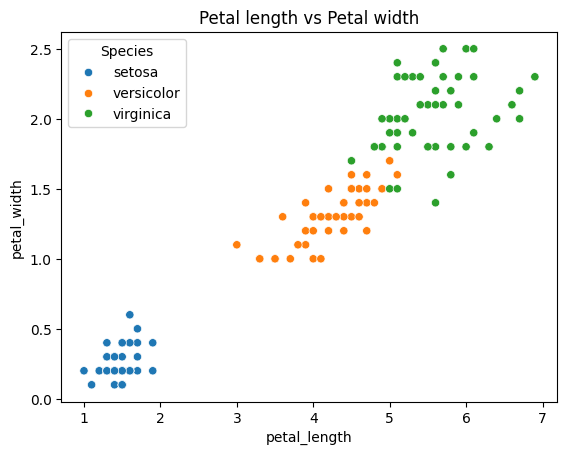

In [40]:
sns.scatterplot(data=iris, x = "petal_length", y = "petal_width", hue = 'Species')
plt.title("Petal length vs Petal width")
plt.savefig("scatterpltPetal.png")
plt.show()

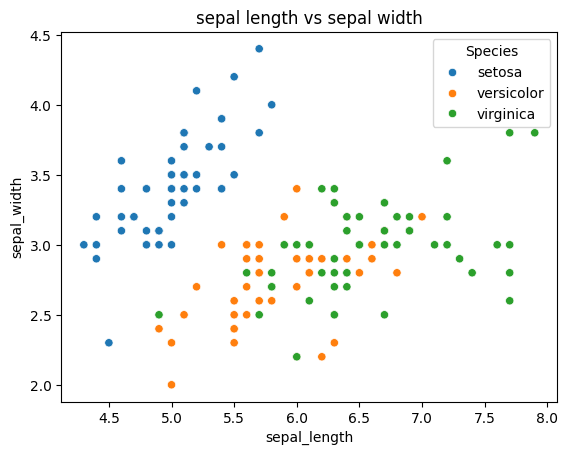

In [41]:
sns.scatterplot(data=iris, x = "sepal_length", y = "sepal_width", hue = 'Species')
plt.title("sepal length vs sepal width")
plt.show()

Introduction to Heat Map with plotting

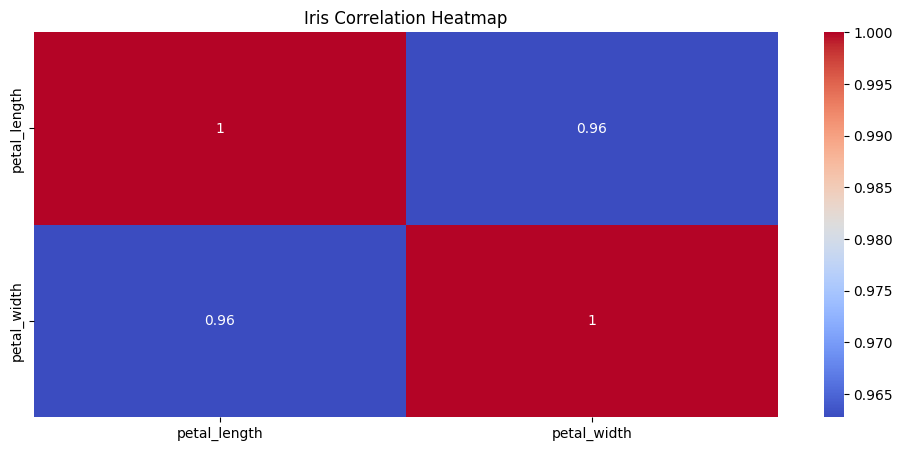

In [42]:
plt.figure(figsize=(12,5))
sns.heatmap(petal_corr, annot = True, cmap= "coolwarm")
plt.title("Iris Correlation Heatmap")
plt.savefig("HeatMap.png")
plt.show()